<a href="https://colab.research.google.com/github/AmnaNoorr/NeuroQuantum-Edge-A-Hybrid-SNN-VQC-Architecture-for-Low-Power-Classification/blob/main/neuro_quantum_edge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane norse snntorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 121.0 MB/s eta 0:00:00
  Created wheel for norse: filename=norse-1.1.0-py3-none-any.whl size=153

In [2]:
import torch
import pennylane as qml
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt


In [5]:
print(torch.__version__)
print(qml.__version__)
print(snn.__version__)
print(np.__version__)

2.11.0+cu128
0.45.1
1.0.0
2.0.2


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

define image transformation. convert to tensor and normalize

In [20]:
dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transforms.ToTensor())
all_images = torch.stack([img for img, _ in dataset])
mean = all_images.mean().item()
std = all_images.std().item()
print("calculated mean:", mean)
print("calculated standard deviation:", std)

calculated mean: 0.13066047430038452
calculated standard deviation: 0.30810782313346863


In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((mean,),(std,))
])

Training

In [22]:
train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root = './data', train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

normalized images

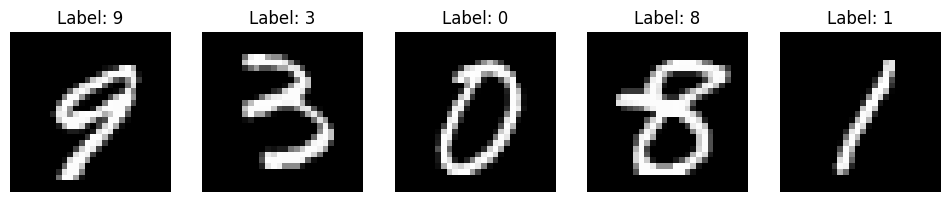

In [23]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
  img = images[i].squeeze()

  axes[i].imshow(img, cmap = 'gray')
  axes[i].set_title(f'Label: {labels[i].item()}')
  axes[i].axis('off')

plt.show()

SNN encoder

In [24]:
from snntorch import spikegen

In [28]:
images, labels = next(iter(train_loader))
num_steps = 20
#spike_data = spikegen.rate(images, num_steps = num_steps)
# Reduce the gain to 50% max probability to see the random flickering
spike_data = spikegen.rate(images * 0.5, num_steps=num_steps)

print(f"Original images shape: {images.shape}")
print(f"Encoded spikes shape: {spike_data.shape}")


Original images shape: torch.Size([64, 1, 28, 28])
Encoded spikes shape: torch.Size([20, 64, 1, 28, 28])


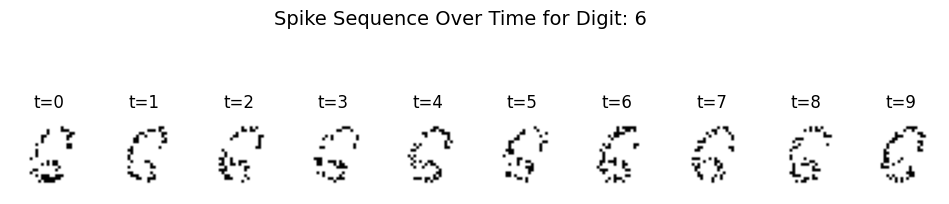

In [29]:
sample_index = 0
sample_label = labels[sample_index].item()
fig, axes = plt.subplots(1, 10, figsize=(12,3))
fig.suptitle(f"Spike Sequence Over Time for Digit: {sample_label}", fontsize=14)
for t in range(10):
  spike_frame = spike_data[t, sample_index].squeeze()
  axes[t].imshow(spike_frame, cmap='binary')
  axes[t].set_title(f"t={t}")
  axes[t].axis('off')
plt.show()

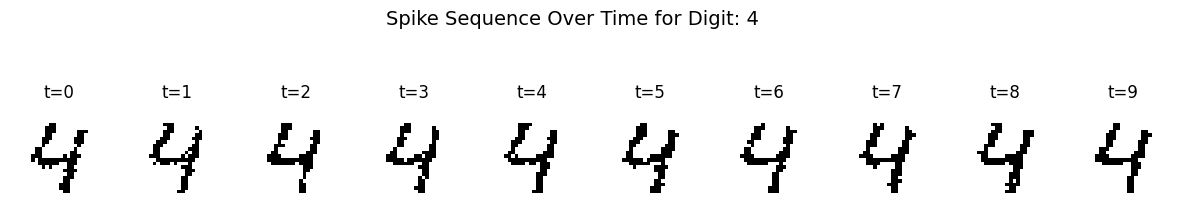

In [27]:
import torch
import snntorch as snn
from snntorch import spikegen
import matplotlib.pyplot as plt

# 1. Grab the batch from your current loader
images, labels = next(iter(train_loader))

# 2. FORCE values strictly between 0 and 1 to fix any background normalization issues
images_min = images.min()
images_max = images.max()
clean_images = (images - images_min) / (images_max - images_min + 1e-5)

# 3. Generate Rate-coded Spikes
num_steps = 20
spike_data = spikegen.rate(clean_images, num_steps=num_steps)

# 4. Plot the time timeline for index 0
sample_index = 0
sample_label = labels[sample_index].item()

fig, axes = plt.subplots(1, 10, figsize=(15, 3))
fig.suptitle(f"Spike Sequence Over Time for Digit: {sample_label}", fontsize=14)

for t in range(10):
    # Pull out frame at time t
    spike_frame = spike_data[t, sample_index].squeeze()

    # Force matplotlib to display it as a true binary mask (0 or 1)
    axes[t].imshow(spike_frame.cpu().numpy(), cmap='binary', vmin=0, vmax=1)
    axes[t].set_title(f"t={t}")
    axes[t].axis('off')

plt.show()
